# Missing Data Analysis

## Imports and Data Loading


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv("../data/processed/processed_telco_customer_churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           6043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            4543 non-null   float64
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   6043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       5543 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## Checking Amount of Missing Values

In [66]:
def check_missing_values(df) -> list:

    """Check for missing values in the dataframe and print:
        - The name of the column
        - The number of missing values in that column compared to total number of rows
        - The percentage of missing values in that column

        If there are no missing values, print "No missing values found in the dataframe."

        Return list of columns with missing values.
    """

    missing_values = df.isnull().sum()

    if missing_values.sum() == 0:
        print("No missing values found in the dataframe.")
    else:
        print("Missing values found in the dataframe:")
        for column, count in missing_values.items():
            if count > 0:
                percentage = (count / len(df)) * 100
                print(f"    {column} - {count} / {len(df)} | {percentage:.2f}%")

    return missing_values[missing_values > 0].index.tolist()

In [67]:
columns_with_missing_values = check_missing_values(df)

Missing values found in the dataframe:
    gender - 750 / 7043 | 10.65%
    Partner - 1000 / 7043 | 14.20%
    tenure - 2500 / 7043 | 35.50%
    InternetService - 1000 / 7043 | 14.20%
    StreamingTV - 1500 / 7043 | 21.30%
    MonthlyCharges - 1500 / 7043 | 21.30%
    TotalCharges - 11 / 7043 | 0.16%


## Heatmap of Missingness

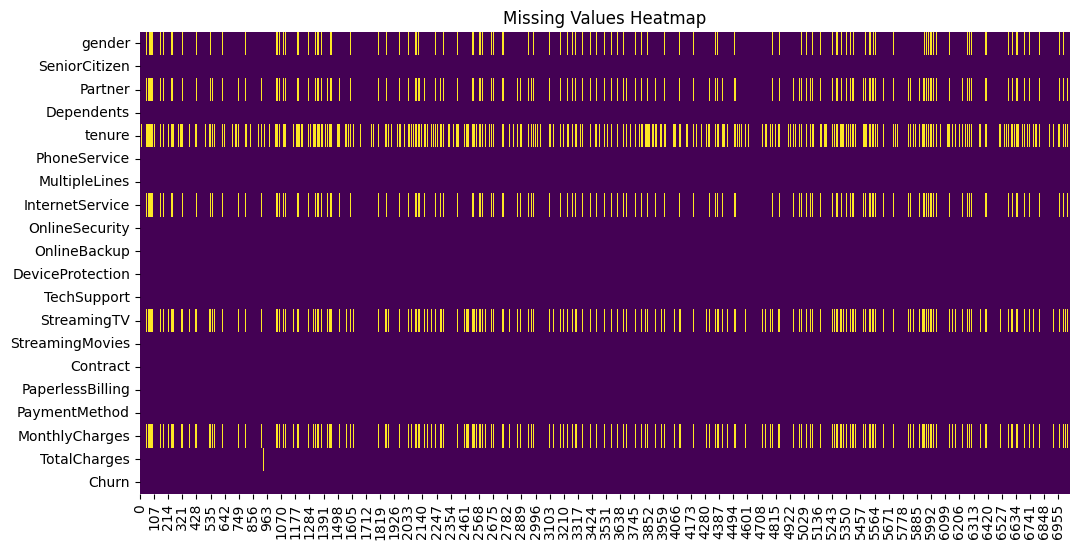

In [68]:
# draw heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull().T, cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

At first sight this missing values heatmap proves to be very interesting.

On a first thought I imagined some columns would have overlapped missing values, especially `InternetService` and `StreamingTV` where missingness could be related to a lack of signature to a service, but the distribution of the missingness looks, at least visually, completely randomized, which would make sense given the dataset origin.

Since the missing data is synthetic, it would make sense that the author injected the synthetic missing data in blocks, deleting multiple values from the same rows simultaneously, let's plot a correlation missingness heatmap to see if that theory holds up. 

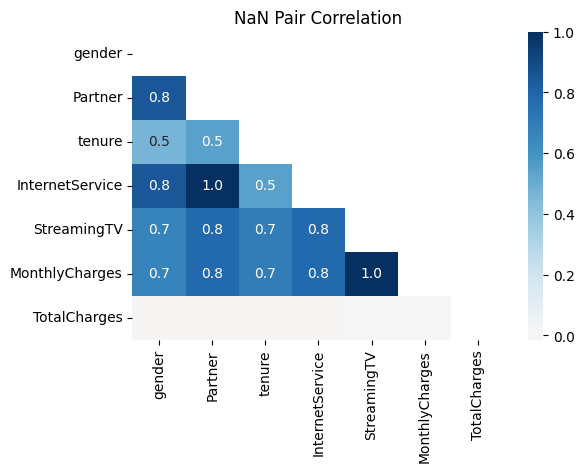

In [69]:
nan_pair_corr = df[columns_with_missing_values].isnull().corr()
mask = np.triu(np.ones_like(nan_pair_corr, dtype=bool))
annot_custom = nan_pair_corr.map(lambda v: f'{v:.1f}' if abs(v) > 0.05 else "")

plt.figure(figsize=(6, 4))
sns.heatmap(nan_pair_corr,mask=mask, cmap='RdBu', center=0, annot=annot_custom, fmt='')
plt.title("NaN Pair Correlation")
plt.show()

There's two pairs of variables with a perfect 1.0 correlation:
- `InternetService` and `Partner`
- `StreamingTV` and `MonthlyCharges`

A score of 1.0 means these variables are missing in the exact same rows - if a customer is missing their `InternetService` data, they are guaranteed to also be missing their `Partner` data in this dataset. This strongly suggests the theory of synthetically injecting data in blocks.

The other correlation values seem to be also really high, which raises a question - **if there is multiple missing values in a same row, does it make sense to keep the corrupted row or is it better to impute?**

The column `TotalCharges` seems to not be correlated with any of the other columns. Accordingly to the documentation, `TotalCharges` is "Total amount charged over the customer's tenure", which would mean that new customers have nothing to pay for and the `NaN` values could simply mean 0. This would be a textbook case of structural missingness. It should be interesting to confirm this theory and also check if other columns might follow the same structural missing pattern.

## Amount Of Missing Values per Row

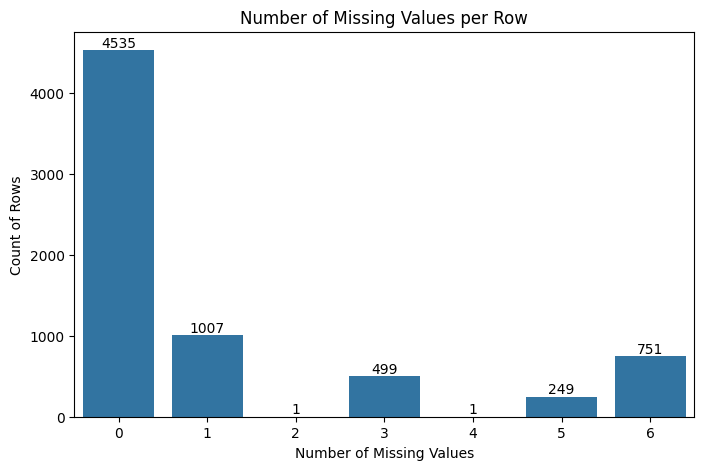

np.int64(2508)

In [78]:
# plot number of missing values per row, place numbers on top of bars, return number of rows with >= 1 missing values

def missing_values_per_row(df) -> int:
    
    missing_counts = df.isnull().sum(axis=1)
    
    missing_greater_than_zero = (missing_counts >= 1).sum()

    fig, ax = plt.subplots(figsize=(8, 5))
    
    sns.countplot(x=missing_counts, ax=ax)
    ax.set_title("Number of Missing Values per Row")
    ax.set_xlabel("Number of Missing Values")
    ax.set_ylabel("Count of Rows")

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

    plt.show()

    return missing_greater_than_zero


missing_values_per_row(df)

In [76]:
2508 / df.shape[0] 

0.35609825358512

If the columns with $>= 1$ missing values were to be dropped ~35.6% of the data would be lost, which is a significant amount of data points. An analysis of each column with missing values should be done to see if the imputation would introduce inbalance in categorical features or a big distortion in the numerical features.

In [81]:
categorical_with_missing_values = df[columns_with_missing_values].select_dtypes(include=['str', 'object']).columns.tolist()
numerical_with_missing_values = df[columns_with_missing_values].select_dtypes(include=np.number).columns.tolist()

In [83]:
for col in categorical_with_missing_values:
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False, normalize=True))
    print("\n")

Column: gender
gender
Male      0.454636
Female    0.438875
NaN       0.106489
Name: proportion, dtype: float64


Column: Partner
Partner
No     0.442283
Yes    0.415732
NaN    0.141985
Name: proportion, dtype: float64


Column: InternetService
InternetService
Fiber optic    0.377680
DSL            0.295613
No             0.184722
NaN            0.141985
Name: proportion, dtype: float64


Column: StreamingTV
StreamingTV
No                     0.312225
Yes                    0.304700
NaN                    0.212977
No internet service    0.170098
Name: proportion, dtype: float64




In [84]:
df[numerical_with_missing_values].describe()

,tenure,MonthlyCharges,TotalCharges
count,4543.000000,5543.000000,7032.000000
mean,32.546555,64.876403,2283.300441
std,24.505519,30.101331,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.750000,401.450000
50%,29.000000,70.550000,1397.475000
75%,56.000000,89.925000,3794.737500
max,72.000000,118.600000,8684.800000


## Structural Missingness

In [71]:
def check_structural_missingness(df, column_with_missing_values) -> None:

    """Check for structural missingness in the dataframe by:
        - Printing the name of the column with possible structural missingness
        - Printing the column that indicates possible structural missingness and the value that indicates it
    """

    for column in df.columns:
        if column in column_with_missing_values:
            missing_rows = df[df[column].isnull()]
            for other_column in df.columns:
                if other_column != column:
                    # if all missing values in 'column' correspond to the same value in 'other_column'
                    if missing_rows[other_column].nunique() == 1: 
                        print(f" Possible structural missingness found in column '{column}' due to column '{other_column}'")
                        print(f"- All missing values in '{column}' correspond to the same value in '{other_column}': {missing_rows[other_column].iloc[0]} \n")


In [72]:
check_structural_missingness(df, columns_with_missing_values)

 Possible structural missingness found in column 'TotalCharges' due to column 'SeniorCitizen'
- All missing values in 'TotalCharges' correspond to the same value in 'SeniorCitizen': No 

 Possible structural missingness found in column 'TotalCharges' due to column 'Dependents'
- All missing values in 'TotalCharges' correspond to the same value in 'Dependents': Yes 

 Possible structural missingness found in column 'TotalCharges' due to column 'tenure'
- All missing values in 'TotalCharges' correspond to the same value in 'tenure': 0.0 

 Possible structural missingness found in column 'TotalCharges' due to column 'Churn'
- All missing values in 'TotalCharges' correspond to the same value in 'Churn': No 



`TotalCharges` seems to have a structural missing relationship with `tenure` which gives more strength to the theory, so we'll treat it as Structural Missingness and to impute it we'll simply use the regular formula:
$$ TotalCharges = tenure * MonthlyCharges$$


Other features don't seem to have any structural relationship between each other.
